# III. Prescriptive / Multivariate Analysis

## Hospitalized Patients with Heart Failure

### Objective

The Descriptive Analysis established the baseline characteristics, clinical severity, comorbidity burden, laboratory patterns, treatment patterns, hospitalization outcomes, and readmission/mortality rates in the cohort.

The Prescriptive / Multivariate Analysis builds on those findings by investigating relationships between multiple clinical, demographic, treatment, and outcome variables.

The objective is to identify:

- factors associated with clinical severity and outcomes,
- combinations of factors that identify different patient profiles,
- relationships between clinical condition and hospitalization/resource use,
- factors that provide information beyond individual severity measures,
- and evidence-supported candidate features for the Predictive Analysis.

Rather than analyzing variables independently, this stage focuses on clinically meaningful relationships and combinations of variables.

### Analytical Flow

Descriptive Findings
        ↓
Identify Important Patterns
        ↓
Formulate Analytical Questions
        ↓
Test Relationships and Interactions
        ↓
Identify Meaningful Patient Profiles
        ↓
Evaluate Incremental Information
        ↓
Select Evidence-Supported Candidate Predictors
        ↓
Predictive Analysis

## 1. Import Libraries
The Prescriptive Analysis requires statistical comparisons, association testing, subgroup analysis, and visualization.
We will use a focused set of Python libraries rather than importing unnecessary packages.


In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf


# Statistical analysis
from scipy import stats
from scipy.stats import chi2
from scipy.stats import chi2_contingency
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Cleaned Master Patient Dataset
The data-cleaning stage has already produced the patient-level analytical dataset.

The Prescriptive Analysis should use the cleaned master dataset so that all questions are based on the same patient population and the same previously validated definitions.

#### What will we do?
Load the finalized `patient_master.csv` created during the Data Cleaning stage.

A single patient-level dataset containing the clinical, demographic, hospitalization, outcome, and treatment information required for the Prescriptive Analysis.

In [ ]:
from pathlib import Path

# Try the team's original path first, then common locations near this notebook.
DATA_PATH = Path(
    r"C:\Users\arunj\Documents\pythonhack"
)
candidates = [DATA_PATH / "cleaned_datafile" / "patient_master.csv"]
for base in [Path.cwd(), *Path.cwd().parents]:
    candidates += [base / "cleaned_datafile" / "patient_master.csv",
                   base / "patient_master.csv"]

MASTER_PATH = next((p for p in candidates if p.is_file()), None)
if MASTER_PATH is None:
    raise FileNotFoundError(
        "Could not find patient_master.csv. Run the final cleaning notebook, "
        "then put the CSV in cleaned_data/ beside this notebook."
    )
CLEANED_PATH = MASTER_PATH.parent
df = pd.read_csv(MASTER_PATH)
print("Master dataset loaded:", MASTER_PATH)
print(f"Rows: {len(df):,}; columns: {df.shape[1]:,}")

## 3. Analytical Dataset Validation

Before beginning multivariate analysis, we need to confirm that the analytical dataset has the expected patient-level structure.
This prevents accidental use of duplicate records, incorrect joins, or unexpected changes to the cleaned dataset.

- Number of patients
- Unique patient identifiers
- Duplicate patient records
- Availability of key variables
- Data types of variables used in Category 3

Confirm that the Prescriptive Analysis is based on the same 2,008-patient master cohort established during data cleaning.

In [4]:
# Verify patient-level structure and names from the final cleaning notebook.
print("Dataset shape:", df.shape)
print("Unique patients:", df["inpatient_number"].nunique())
print("Duplicate patient IDs:", df["inpatient_number"].duplicated().sum())
key_variables = [
    "inpatient_number", "glomerular_filtration_rate", "cci_score",
    "nyha_cardiac_function_classification", "killip_grade",
    "brain_natriuretic_peptide", "dischargeday",
    "re_admission_within_6_months", "death_within_6_months",
    "age_category", "diabetes", "moderate_to_severe_chronic_kidney_disease"
]
available = [name for name in key_variables if name in df.columns]
missing = [name for name in key_variables if name not in df.columns]
print("Available:", available)
print("Missing:", missing)
if missing or df["inpatient_number"].duplicated().any():
    raise ValueError("The master CSV does not match the final cleaned patient dataset.")

Dataset shape: (2008, 198)
Unique patients: 2008
Duplicate patient IDs: 0
Available: ['inpatient_number', 'glomerular_filtration_rate', 'cci_score', 'nyha_cardiac_function_classification', 'killip_grade', 'brain_natriuretic_peptide', 'dischargeday', 're_admission_within_6_months', 'death_within_6_months', 'age_category', 'diabetes', 'moderate_to_severe_chronic_kidney_disease']
Missing: []


### 4. Transition from Descriptive to Prescriptive / Multivariate Analysis

The Descriptive Analysis established several important characteristics of the cohort.

Key observations included:

- A substantial proportion of patients had reduced renal function based on measured GFR.
- The prevalence of the CKD indicator was lower than the proportion with measured GFR <60 mL/min/1.73 m².
- Admission severity was characterized using NYHA and Killip classifications.
- BNP showed a strongly right-skewed distribution and varied across NYHA severity groups.
- Comorbidity burden was present across the cohort, with CKD and diabetes among the more prevalent conditions.
- Six-month readmission occurred considerably more frequently than six-month mortality.
- Length of stay varied across patients, and exploratory analysis showed an association between medication burden and length of stay.

These findings generate questions that cannot be answered by descriptive statistics alone.

The Prescriptive / Multivariate Analysis therefore moves from:

**"What do we observe?"**

to: **"How are these factors related, do they provide additional information when considered together, and which combinations identify meaningful patient profiles?"**

## Section 1 — Renal Function & Admission Severity

### Q1. Does the CKD flag identify the same renal-risk population as measured GFR <60 mL/min/1.73m²?

**Why:** Descriptive analysis flagged a gap between the coded CKD comorbidity indicator and the share of patients with measured GFR<60. The data dictionary defines that exact indicator using the same <60 cutoff, so the two should largely agree — testing whether they actually do determines which one we trust as the primary renal-risk variable for every downstream question in this section.

**What We Expect:** Given the shared cutoff, we expect substantial but not perfect overlap — some disagreement is plausible if the CKD flag reflects a historical diagnosis while GFR reflects current lab values, but a large gap would suggest the flag under-captures current renal risk.

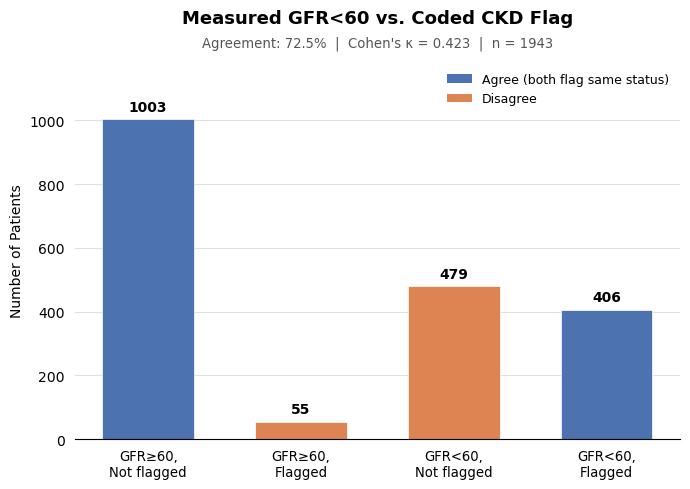

In [7]:
# Recreate the contingency table so the starter Q1 chart works when run from the top.
q1 = df[["glomerular_filtration_rate", "moderate_to_severe_chronic_kidney_disease"]].copy()
q1["glomerular_filtration_rate"] = pd.to_numeric(q1["glomerular_filtration_rate"], errors="coerce")
q1["moderate_to_severe_chronic_kidney_disease"] = pd.to_numeric(
    q1["moderate_to_severe_chronic_kidney_disease"], errors="coerce"
)
q1 = q1.dropna()
q1 = q1[q1["moderate_to_severe_chronic_kidney_disease"].isin([0, 1])]
q1["low_gfr"] = (q1["glomerular_filtration_rate"] < 60).astype(int)
ct = pd.crosstab(q1["low_gfr"], q1["moderate_to_severe_chronic_kidney_disease"])
ct = ct.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
n = int(ct.to_numpy().sum())
if n == 0:
    raise ValueError("No usable GFR and CKD flag pairs for the Q1 chart.")
po = (ct.loc[0, 0] + ct.loc[1, 1]) / n
row_share = ct.sum(axis=1) / n
col_share = ct.sum(axis=0) / n
pe = row_share.loc[0] * col_share.loc[0] + row_share.loc[1] * col_share.loc[1]
kappa = (po - pe) / (1 - pe) if pe < 1 else float("nan")
display(ct.rename(index={0: "GFR >=60", 1: "GFR <60"},
                  columns={0: "CKD not flagged", 1: "CKD flagged"}))

# Visualization — cleaner version
fig, ax = plt.subplots(figsize=(7, 5))

labels = ["GFR≥60,\nNot flagged", "GFR≥60,\nFlagged", "GFR<60,\nNot flagged", "GFR<60,\nFlagged"]
values = [ct.loc[0,0], ct.loc[0,1], ct.loc[1,0], ct.loc[1,1]]

agree_color = "#4C72B0"     # the two cells where GFR and flag agree
disagree_color = "#DD8452"  # the two cells where they disagree
colors = [agree_color, disagree_color, disagree_color, agree_color]

bars = ax.bar(labels, values, color=colors, width=0.6, edgecolor="white", linewidth=0.5)

# Labels above bars, with enough headroom so nothing touches the top
ax.bar_label(bars, padding=4, fontsize=10, fontweight="bold")
ax.set_ylim(0, max(values) * 1.18)

# Clean up the frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(left=False, bottom=False)

ax.set_ylabel("Number of Patients", fontsize=10)
ax.set_title("Measured GFR<60 vs. Coded CKD Flag", fontsize=13, fontweight="bold", pad=28)
ax.text(0.5, 1.04, f"Agreement: {po*100:.1f}%  |  Cohen's κ = {kappa:.3f}  |  n = {n}",
        transform=ax.transAxes, ha="center", fontsize=9.5, color="#555555")

plt.xticks(fontsize=9.5)

# Legend explaining the color coding
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=agree_color, label="Agree (both flag same status)"),
    Patch(facecolor=disagree_color, label="Disagree"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

**Finding**

885/1,943 (45.55%) have GFR<60; only 461 (23.73%) carry the CKD flag. 479 patients (24.7%) are low-GFR but unflagged; only 55 (2.8%) are flagged with normal GFR. Agreement = 72.5%, but Cohen's κ = 0.423 (moderate, not strong). Chi-square p ≈ 2.46e-97 — significant, but with n=1,943 that reflects sample size, not interchangeability.

**Observation & Implication**

The two measures disagree more than they agree meaningfully (κ=0.423), and the flag under-catches far more than it over-flags. Measured GFR will be used as the primary renal-function variable going forward; the CKD flag stays separate as a comorbidity variable, not a GFR proxy. Sets up Q2 (GFR vs. severity) using the lab value.

**Counter-Argument:** CKD is a chronic diagnosis — some "missed" patients may just have a normal GFR at this admission despite a history of impairment. Doesn't change the choice: current GFR is still the right variable for a cross-sectional analysis.

## Family 3 — Cardiac Biomarker and Renal Function (Questions 11–13)

These analyses use the final `patient_master.csv`. Each question builds a *new*
working table, so it can be run without variables created by another family's
question. Percentages always use patients with a recorded outcome and marker;
a missing biomarker or outcome never counts as a negative result. Results show
associations in these patients, not treatment effects or confirmed clinical risk scores.

In [ ]:
# Step 1: Set exact column names produced by the team's cleaning notebook.
OUTCOME = "re_admission_within_6_months"
DEATH = "death_within_6_months"
BNP = "brain_natriuretic_peptide"
GFR = "glomerular_filtration_rate"
NYHA = "nyha_cardiac_function_classification"
KILLIP = "killip_grade"
CCI = "cci_score"
CKD = "moderate_to_severe_chronic_kidney_disease"

# Step 2: Report counts and observed rates using the correct group denominators.
# Missing outcomes are excluded BEFORE this function is called.
def outcome_rates(frame, groups, outcome):
    result = (frame.groupby(groups, observed=True, dropna=False)[outcome]
              .agg(n="size", events="sum"))
    result["rate_pct"] = (100 * result["events"] / result["n"]).round(1)
    return result

# Step 3: Make a complete-case working copy without changing the master df.
# The cleaning notebook marked a small number of contradictory event records;
# exclude them from analyses of the 6-month readmission label when the flag exists.
def analysis_rows(columns, outcome=OUTCOME):
    cols = list(dict.fromkeys([*columns, outcome]))
    if "event_time_contradiction_flag" in df.columns and outcome == OUTCOME:
        cols.append("event_time_contradiction_flag")
    if "outcome_destination_flag" in df.columns and outcome == DEATH:
        cols.append("outcome_destination_flag")
    work = df[cols].copy()
    if "event_time_contradiction_flag" in work:
        work = work.loc[~work["event_time_contradiction_flag"].astype(str)
                        .str.strip().str.lower().isin(["true", "1"])].drop(columns="event_time_contradiction_flag")
    if "outcome_destination_flag" in work:
        work = work.loc[~work["outcome_destination_flag"].astype(str)
                        .str.strip().str.lower().isin(["true", "1"])].drop(columns="outcome_destination_flag")
    for name in cols:
        if name in work and name != "age_category":
            work[name] = pd.to_numeric(work[name], errors="coerce")
    work = work.dropna(subset=list(dict.fromkeys([*columns, outcome])))
    work = work.loc[work[outcome].isin([0, 1])].copy()
    print(f"Usable patients: {len(work):,} of {len(df):,}; {outcome} events: {int(work[outcome].sum()):,}")
    return work

# Step 4: Use the SAME complete cases for each pair of nested logistic models.
# A likelihood-ratio test asks whether the added columns explain outcome
# variation beyond the smaller model; neither model establishes causality.
from scipy.optimize import minimize
def nested_logistic_test(y, base, added):
    y = np.asarray(y, dtype=float)
    base = np.asarray(base, dtype=float).reshape(len(y), -1)
    added = np.asarray(added, dtype=float).reshape(len(y), -1)
    if len(np.unique(y)) < 2:
        print("Both outcome classes are needed; interaction test not estimable.")
        return np.nan, np.nan
    def fit(x):
        x = np.column_stack([np.ones(len(y)), x])
        result = minimize(lambda beta: np.logaddexp(0, x @ beta).sum()
                          - y @ (x @ beta), np.zeros(x.shape[1]), method="L-BFGS-B")
        if not result.success:
            print("Model optimization warning:", result.message)
        return -float(result.fun)
    lr = max(0.0, 2 * (fit(np.column_stack([base, added])) - fit(base)))
    p = stats.chi2.sf(lr, added.shape[1])
    return lr, p

# Severity rule shared by Q13 and Q18. This is an exploratory grouping,
# explicitly defined here so the result cannot be changed after seeing it.
def severe_presentation(frame):
    return (frame[NYHA] >= 4) | (frame[KILLIP] >= 3)

# Anchor subgroup percentages to the overall rates the descriptive
# notebook reported. Subsequent analyses may exclude flagged/missing rows.
for target in [OUTCOME, DEATH]:
    known = pd.to_numeric(df[target], errors="coerce")
    known = known[known.isin([0, 1])]
    print(f"Full-cohort {target}: {int(known.sum())}/{len(known)} = {known.mean():.1%}")
print("Shared helpers ready; master dataframe left unchanged.")

### Q11. Is higher BNP associated with higher six-month readmission?

**Why:** BNP is a heart-failure biomarker. Comparing *readmission rates* across
BNP levels tests whether patients with higher recorded BNP have different
follow-up outcomes. Quartiles are derived from nonmissing BNP values in this
dataset, so they are data groupings rather than clinical cutoffs.

**How:** Remove missing/invalid BNP and missing outcomes; report group size,
readmissions, and within-group rates. Use a chi-square comparison and a
patient-level rank trend as supporting evidence. Also print the BNP boundaries.

In [ ]:
# Step 1: Keep patients with nonmissing BNP and a known binary outcome.
q11 = analysis_rows([BNP])
q11 = q11.loc[q11[BNP] >= 0].copy()
print("Nonnegative BNP measurements:", len(q11))

# Step 2: Rank BNP, then make four roughly equal-sized groups. Ranking
# avoids qcut's duplicate-edge error if several patients have the same BNP.
q11["BNP_quartile"] = pd.qcut(q11[BNP].rank(method="first"), 4,
                              labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
print("BNP by group (min / median / max):")
display(q11.groupby("BNP_quartile", observed=True)[BNP].agg(["min", "median", "max"]))
q11_rates = outcome_rates(q11, "BNP_quartile", OUTCOME)
display(q11_rates)

# Step 3: Compare observed rates and test whether their distribution differs.
cont = pd.crosstab(q11["BNP_quartile"], q11[OUTCOME])
chi2, p, _, expected = chi2_contingency(cont)
rank_r, trend_p = stats.spearmanr(q11["BNP_quartile"].cat.codes, q11[OUTCOME])
print(f"Chi-square p={p:.4g}; rank association r={rank_r:.3f}, p={trend_p:.4g}")
if (expected < 5).any():
    print("Some expected cell counts are below 5; interpret chi-square cautiously.")

# Step 4: Plot percentages AND show the patient counts on each bar.
ax = q11_rates["rate_pct"].plot.bar(figsize=(8, 4), color="#4169a2", rot=0)
ax.set(ylabel="Six-month readmission (%)", xlabel="BNP group",
       title="Six-month readmission across BNP quartiles")
for bar, count in zip(ax.patches, q11_rates["n"]):
    ax.annotate(f"n={count}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.ylim(0, max(5, q11_rates["rate_pct"].max() * 1.22))
plt.tight_layout(); plt.show()
print("Interpretation: compare Q4 with Q1 using the displayed rates and group sizes;")
print("a p-value or rising pattern alone does not show BNP causes readmission.")

### Q12. Does BNP add information about six-month readmission beyond NYHA and Killip?

**Why:** BNP could reflect information already captured by severity grades.
Test whether adding it to the two severity measures improves separation of
readmitted versus non-readmitted patients *on the same complete-case sample*.

**How:** Compare severity-only and severity-plus-BNP logistic models with
five-fold cross-validated ROC AUC. The likelihood-ratio test offers a separate
measure of association after accounting for NYHA and Killip. This is exploratory
analysis, not a validated clinical prediction model.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss

# Step 1: Same complete patients and outcomes for BOTH model comparisons.
q12 = analysis_rows([NYHA, KILLIP, BNP])
q12 = q12.loc[q12[BNP] >= 0].copy()
q12["log_BNP"] = np.log1p(q12[BNP])  # Compress the right-skewed BNP distribution.
baseline = q12[[NYHA, KILLIP]].to_numpy()
expanded = q12[[NYHA, KILLIP, "log_BNP"]].to_numpy()
y12 = q12[OUTCOME].astype(int).to_numpy()

# Step 2: Split data into the same stratified folds for both models.
folds = min(5, np.bincount(y12).min())
if folds < 2:
    raise ValueError("Not enough outcomes in both classes for Q12 validation.")
cv12 = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
results12 = {}
for name, x in [("NYHA + Killip", baseline), ("NYHA + Killip + BNP", expanded)]:
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    probabilities = cross_val_predict(model, x, y12, cv=cv12, method="predict_proba")[:, 1]
    results12[name] = [roc_auc_score(y12, probabilities),
                       brier_score_loss(y12, probabilities)]
comparison12 = pd.DataFrame(results12, index=["CV ROC AUC (higher better)",
                                             "CV Brier score (lower better)"]).T
display(comparison12.round(3))

# Step 3: Test whether BNP is associated with the outcome after accounting
# for the two severity grades on these same patients.
lr12, p12 = nested_logistic_test(y12, baseline, q12[["log_BNP"]])
print(f"BNP added to NYHA + Killip: likelihood-ratio statistic={lr12:.2f}, p={p12:.4g}")
print("Interpretation: compare BOTH AUC and Brier scores. A small/negative")
print("change in held-out performance would not support a useful added signal.")

### Q13. Does the combination of admission severity, BNP and renal function identify a different readmission subgroup?

**Why:** These measures represent different clinical domains. We examine whether
patients with none, one, two, or all three recorded signals show different
observed outcomes, while checking the number of patients in every subgroup.

**Group rules:** severe presentation = NYHA 4 **or** Killip 3–4;
higher BNP = at or above the *complete-case cohort median*; low GFR = <60.
These are exploratory categories, not clinical recommendations.

In [ ]:
# Step 1: Restrict to patients who have all three markers AND outcome recorded.
q13 = analysis_rows([NYHA, KILLIP, BNP, GFR])
q13 = q13.loc[(q13[BNP] >= 0) & (q13[GFR] > 0)].copy()
median_bnp13 = q13[BNP].median()
q13["severe"] = severe_presentation(q13).astype(int)
q13["high_BNP"] = (q13[BNP] >= median_bnp13).astype(int)
q13["low_GFR"] = (q13[GFR] < 60).astype(int)
q13["signals"] = q13[["severe", "high_BNP", "low_GFR"]].sum(axis=1)
print(f"Exploratory high-BNP boundary: >= {median_bnp13:.2f} (dataset median)")

# Step 2: Compare rates with their denominators; 0 vs 3 is useful only if
# both groups have enough observations to interpret.
rates13 = outcome_rates(q13, "signals", OUTCOME).reindex([0, 1, 2, 3], fill_value=0)
display(rates13)
print("Every combination (S=severe, B=higher BNP, R=low GFR):")
profiles13 = outcome_rates(q13, ["severe", "high_BNP", "low_GFR"], OUTCOME)
display(profiles13)
if (profiles13["n"] < 20).any():
    print("CAUTION: one or more profiles have fewer than 20 patients.")

# Association test for the prespecified 0–3 signal count. A rate gradient
# supports an association only if the sample sizes and trend also support it.
rho13, p13 = stats.spearmanr(q13["signals"], q13[OUTCOME])
print(f"Signal-count/readmission rank association: r={rho13:.3f}, p={p13:.4g}")

# Step 3: Visualize observed rates; show n above each bar to avoid hiding
# an unstable high percentage in a small subgroup.
ax = rates13["rate_pct"].plot.bar(figsize=(7, 4), rot=0, color="#6c8fa8")
ax.set(xlabel="Number of signals present (0–3)",
       ylabel="Six-month readmission (%)", title="Observed readmission by combined profile")
for bar, count in zip(ax.patches, rates13["n"]):
    ax.annotate(f"n={count}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.ylim(0, max(5, rates13["rate_pct"].max()*1.2))
plt.tight_layout(); plt.show()
print("Interpretation: report both the 0-vs-3 rate difference and the sample")
print("sizes; these categories must not be treated as a validated score.")

## Family 4 — Comorbidity and Demographic Risk (Questions 14–18)

We use the recorded Charlson comorbidity index (`cci_score`), recorded
diagnosis flags, and age *categories* from the cleaning notebook. The age
file has bands, not each patient's exact age. Most questions use six-month
readmission; Q15 uses the separate, rarer six-month death indicator.

### Q14. Is higher CCI associated with higher six-month readmission?

**Why:** A higher CCI summarizes more recorded comorbidity burden. Groups
0–1, 2 and 3+ preserve a usable size in each category; they do not imply
that the score itself changes the patient's outcome.

In [ ]:
# Step 1: Keep a known CCI and known readmission outcome.
q14 = analysis_rows([CCI])
q14 = q14.loc[q14[CCI] >= 0].copy()
q14["CCI_group"] = pd.cut(q14[CCI], [-0.1, 1, 2, np.inf],
                          labels=["0–1", "2", "3+"])

# Step 2: Calculate within-group readmission rates and event counts.
rates14 = outcome_rates(q14, "CCI_group", OUTCOME)
display(rates14)
table14 = pd.crosstab(q14["CCI_group"], q14[OUTCOME])
chi2_14, p14, _, expected14 = chi2_contingency(table14)
rho14, trend14 = stats.spearmanr(q14[CCI], q14[OUTCOME])
print(f"Group comparison p={p14:.4g}; CCI rank association r={rho14:.3f}, p={trend14:.4g}")
if (expected14 < 5).any():
    print("Small expected counts: chi-square p-value may be unreliable.")

# Step 3: Show both denominators and rates; report what the actual pattern says.
ax = rates14["rate_pct"].plot.bar(figsize=(6, 4), rot=0, color="#4e7893")
ax.set(xlabel="CCI score", ylabel="Six-month readmission (%)",
       title="Comorbidity burden and readmission")
for bar, count in zip(ax.patches, rates14["n"]):
    ax.annotate(f"n={count}", (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom")
plt.ylim(0, max(5, rates14["rate_pct"].max()*1.2))
plt.tight_layout(); plt.show()
print("Interpretation: describe whether the displayed rates increase with CCI;")
print("if they do not, the original hypothesis is not supported here.")

### Q15. Is higher CCI associated with six-month mortality?

**Why:** A death outcome may show a different pattern from readmission.
Deaths are less frequent, so we report raw death counts and use Fisher's
exact test for a clearly defined comparison (CCI 3+ versus 0–2).
Small numbers can produce unstable percentages.

In [ ]:
# Step 1: Select known CCI and recorded mortality; exclude flagged
# destination/outcome contradictions when the cleaning file supplies the flag.
q15 = analysis_rows([CCI], outcome=DEATH)
q15 = q15.loc[q15[CCI] >= 0].copy()
q15["CCI_group"] = pd.cut(q15[CCI], [-0.1, 1, 2, np.inf],
                          labels=["0–1", "2", "3+"])
deaths15 = outcome_rates(q15, "CCI_group", DEATH)
display(deaths15.rename(columns={"events": "deaths"}))

# Step 2: Compare two broad groups using an exact test for uncommon deaths.
q15["CCI_3plus"] = q15[CCI] >= 3
mortality_table = pd.crosstab(q15["CCI_3plus"], q15[DEATH]).reindex(
    index=[False, True], columns=[0.0, 1.0], fill_value=0)
display(mortality_table.rename(index={False: "CCI 0–2", True: "CCI 3+"},
                               columns={0.0: "Alive at six months", 1.0: "Died by six months"}))
odds15, p15 = stats.fisher_exact(mortality_table.to_numpy())
print(f"CCI 3+ vs 0–2: Fisher exact p={p15:.4g}; sample odds ratio={odds15:.2f}")
print(f"Total six-month deaths in comparison: {int(q15[DEATH].sum())}")
if (deaths15["events"] < 5).any():
    print("CAUTION: fewer than 5 deaths in a group; compare counts and avoid strong conclusions.")

### Q16. Do common individual comorbidities add information beyond CCI?

**Why:** CCI combines diagnoses into one number. We compare that number
alone with CCI plus three adequately prevalent, recorded flags: diabetes,
moderate-to-severe CKD and COPD. On *the same patients*, compare held-out
readmission separation. Also show each condition's observed yes/no rates.

**Important:** The CKD flag and diabetes may contribute to CCI itself;
improvement is not proof that any condition causes readmission.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, brier_score_loss

# Step 1: Fix the condition set before comparing models.
conditions16 = ["diabetes", CKD, "chronic_obstructive_pulmonary_disease"]
q16 = analysis_rows([CCI] + conditions16)
q16 = q16.loc[(q16[CCI] >= 0) & q16[conditions16].isin([0, 1]).all(axis=1)].copy()
for condition in conditions16:
    print("Condition:", condition)
    display(outcome_rates(q16, condition, OUTCOME).rename(index={0: "Absent", 1: "Present"}))

# Step 2: Compare two models in identical held-out folds on identical rows.
y16 = q16[OUTCOME].astype(int).to_numpy()
folds16 = min(5, np.bincount(y16).min())
if folds16 < 2:
    raise ValueError("Not enough cases of both outcome classes for Q16.")
cv16 = StratifiedKFold(n_splits=folds16, shuffle=True, random_state=42)
metrics16 = {}
for name, cols in [("CCI alone", [CCI]), ("CCI + three conditions", [CCI] + conditions16)]:
    x16 = q16[cols].to_numpy()
    model16 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    probabilities16 = cross_val_predict(
        model16, x16, y16, cv=cv16, method="predict_proba")[:, 1]
    metrics16[name] = [roc_auc_score(y16, probabilities16),
                       brier_score_loss(y16, probabilities16)]
display(pd.DataFrame(metrics16, index=["CV ROC AUC (higher better)",
                                        "CV Brier score (lower better)"]).T.round(3))

# Step 3: Nested-model association test complements held-out performance.
lr16, p16 = nested_logistic_test(y16, q16[[CCI]], q16[conditions16])
print(f"Adding three conditions to CCI: likelihood-ratio statistic={lr16:.2f}, p={p16:.4g}")
print("Interpretation: held-out AUC/Brier must also improve to support added")
print("practical information; this analysis does not identify a causal effect.")

### Q17. Does having both CKD and diabetes identify a different six-month readmission profile?

**Why:** Compare patients with neither diagnosis, each diagnosis alone, and
both. A formal interaction test asks whether the combined relationship differs
from what an additive-log-odds model of the separate flags would predict.
A high rate in the both group **by itself** does not establish an interaction.

In [ ]:
# Step 1: Keep recorded (0/1) CKD, diabetes and readmission indicators.
q17 = analysis_rows([CKD, "diabetes"])
q17 = q17.loc[q17[[CKD, "diabetes"]].isin([0, 1]).all(axis=1)].copy()
labels17 = {(0, 0): "Neither", (0, 1): "Diabetes only",
            (1, 0): "CKD only", (1, 1): "Both"}
q17["profile"] = [labels17[(int(ckd), int(dm))]
                  for ckd, dm in zip(q17[CKD], q17["diabetes"])]
ordered17 = ["Neither", "Diabetes only", "CKD only", "Both"]
rates17 = outcome_rates(q17, "profile", OUTCOME).reindex(ordered17)
display(rates17)

# Step 2: Test the CKD × diabetes interaction separately from the group table.
q17["CKD_x_diabetes"] = q17[CKD] * q17["diabetes"]
lr17, p17 = nested_logistic_test(q17[OUTCOME], q17[[CKD, "diabetes"]],
                                 q17[["CKD_x_diabetes"]])
print(f"Interaction likelihood-ratio statistic={lr17:.2f}, p={p17:.4g}")
if (rates17["n"] < 20).any():
    print("CAUTION: at least one diagnosis profile has fewer than 20 patients.")

# Step 3: Show observed rates together with their group sizes.
ax = rates17["rate_pct"].plot.bar(figsize=(7, 4), color="#6c8fa8", rot=15)
ax.set(xlabel="Recorded diagnosis profile", ylabel="Six-month readmission (%)",
       title="CKD, diabetes and observed readmission")
for bar, count in zip(ax.patches, rates17["n"]):
    ax.annotate(f"n={count}", (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom")
plt.ylim(0, max(5, rates17["rate_pct"].max()*1.2))
plt.tight_layout(); plt.show()
print("Interpretation: describe four rates first. Use the interaction p-value")
print("to judge whether 'both' departs from the separate-condition pattern.")

### Q18. Does the relationship between admission severity and readmission differ by age group?

**Why:** The original data reports age *bands*, not exact age. Compare
patients in bands starting at 79 or older with those in bands starting below
79. The high-severity rule is the same as Q13 (NYHA 4 or Killip 3–4).
An interaction test checks whether the relationship between this severity
indicator and readmission differs by age-band group.

**Limit:** The `69–79` and `79–89` labels overlap at the boundary, so the
comparison uses the *recorded band labels*, not a confirmed exact age cutoff.

In [ ]:
# Step 1: Use the age CATEGORY produced by the cleaning notebook. Extract
# only the beginning of the recorded category, never invent an exact age.
q18 = analysis_rows(["age_category", NYHA, KILLIP])
q18["age_band_start"] = pd.to_numeric(
    q18["age_category"].astype(str).str.extract(r"^(\d+)")[0], errors="coerce")
q18 = q18.dropna(subset=["age_band_start"]).copy()
q18["older_band"] = (q18["age_band_start"] >= 79).astype(int)
q18["high_severity"] = severe_presentation(q18).astype(int)
q18["age_band_group"] = q18["older_band"].map({0: "Bands starting <79", 1: "Bands starting 79+"})
q18["severity_group"] = q18["high_severity"].map({0: "Lower", 1: "Higher"})
print("Recorded age categories:")
print(q18["age_category"].value_counts().sort_index().to_string())

# Step 2: Compare all four age-by-severity groups using outcome percentages
# and denominators; rates alone can disguise uneven group sizes.
rates18 = outcome_rates(q18, ["age_band_group", "severity_group"], OUTCOME)
display(rates18)

# Step 3: Formal multiplicative interaction on the log-odds scale.
q18["age_x_severity"] = q18["older_band"] * q18["high_severity"]
lr18, p18 = nested_logistic_test(q18[OUTCOME],
                                q18[["older_band", "high_severity"]],
                                q18[["age_x_severity"]])
print(f"Age-band × severity interaction: likelihood-ratio statistic={lr18:.2f}, p={p18:.4g}")
if (rates18["n"] < 20).any():
    print("CAUTION: one or more age/severity groups have fewer than 20 patients.")

# Step 4: Compare the two severity rates *within each age-band group*.
plot18 = rates18["rate_pct"].unstack("severity_group")
ax = plot18.plot.bar(figsize=(8, 4), rot=0, color=["#70a2c2", "#ba715e"])
ax.set(xlabel="Recorded age group", ylabel="Six-month readmission (%)",
       title="Severity and readmission across age bands")
plt.tight_layout(); plt.show()
print("Interpretation: compare the Lower-to-Higher change in each age group.")
print("A small interaction p-value supports different relationships, not a")
print("claim that chronological age causes the difference.")

### Summary for the team

After running Q11–Q18 on the **actual** `patient_master.csv`, record each
question's group sizes, outcome events, percentage differences, and any model
comparison or interaction result in the presentation. Report unsupported
hypotheses plainly. The hospital records are observational; the results
identify associations and candidate features, not proven interventions.

### Section 5 - Treatment Pattern → Hospital Resource Use¶

# **Section 7 — Discharge & Care Pathway**

**Q28:Is discharge against medical order associated with higher 28-day or 6-month readmission?**

**Why**: Discharge pathway is different from physiological severity and treatment intensity. Including it allows us to examine whether the discharge process is associated with subsequent utilization.

In [5]:
df[[
    "destination_discharge",
    "re_admission_within_28_days",
    "re_admission_within_6_months"
]].head()

,destination_discharge,re_admission_within_28_days,re_admission_within_6_months
0,Home,0,0
1,Home,0,0
2,Home,0,0
3,Home,1,1
4,Home,0,0


In [6]:
df["destination_discharge"].value_counts(dropna=False)

destination_discharge
Home                   1344
Healthcare Facility     438
Unknown                 212
Died                     14
Name: count, dtype: int64

In [7]:
df["destination_discharge"].unique()

<ArrowStringArray>
['Home', 'Healthcare Facility', 'Unknown', 'Died']
Length: 4, dtype: str

In [8]:
print("28-day readmission:")
print(df["re_admission_within_28_days"].value_counts(dropna=False))

print("\n6-month readmission:")
print(df["re_admission_within_6_months"].value_counts(dropna=False))

28-day readmission:
re_admission_within_28_days
0    1868
1     140
Name: count, dtype: int64

6-month readmission:
re_admission_within_6_months
0    1235
1     773
Name: count, dtype: int64


In [9]:
summary = df.groupby("destination_discharge").agg(
    Total_Patients=("inpatient_number", "count"),
    Readmitted_28_Days=("re_admission_within_28_days", "sum"),
    Readmitted_6_Months=("re_admission_within_6_months", "sum")
)

summary

,Total_Patients,Readmitted_28_Days,Readmitted_6_Months
destination_discharge,,,
Died,14,0,0
Healthcare Facility,438,40,180
Home,1344,87,533
Unknown,212,13,60


In [10]:
summary["28_Day_Readmission_Rate_%"] = (
    summary["Readmitted_28_Days"] / summary["Total_Patients"] * 100
)

summary["6_Month_Readmission_Rate_%"] = (
    summary["Readmitted_6_Months"] / summary["Total_Patients"] * 100
)

summary.round(2)

,Total_Patients,Readmitted_28_Days,Readmitted_6_Months,28_Day_Readmission_Rate_%,6_Month_Readmission_Rate_%
destination_discharge,,,,,
Died,14,0,0,0.000,0.000
Healthcare Facility,438,40,180,9.130,41.100
Home,1344,87,533,6.470,39.660
Unknown,212,13,60,6.130,28.300


**Create a comparison chart**

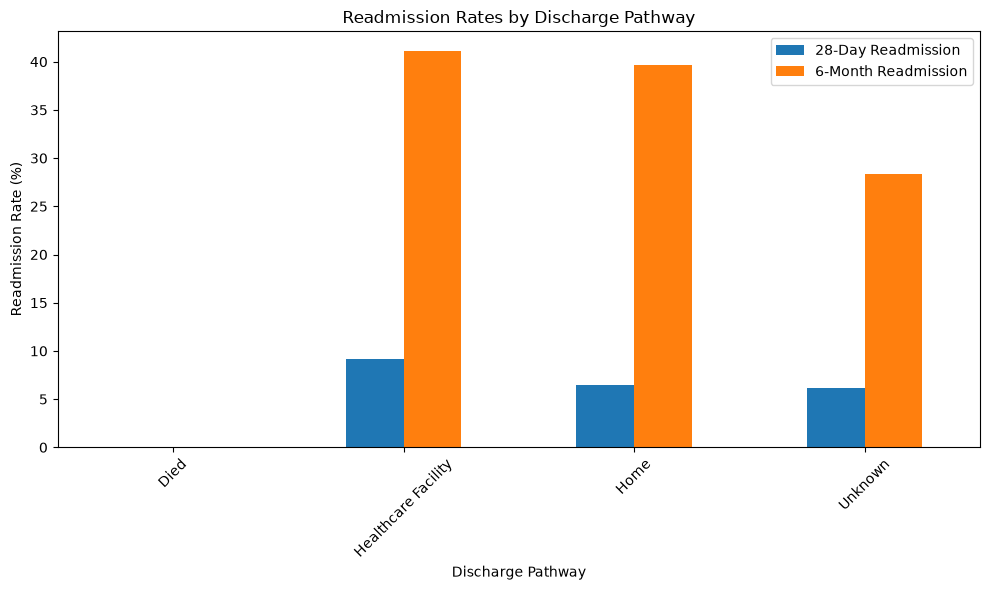

In [11]:
plot_data = summary[
    ["28_Day_Readmission_Rate_%", "6_Month_Readmission_Rate_%"]
]

plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Readmission Rates by Discharge Pathway")
plt.xlabel("Discharge Pathway")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)
plt.legend(
    ["28-Day Readmission", "6-Month Readmission"]
)
plt.tight_layout()
plt.show()


**Create a percentage comparison using a heatmap**

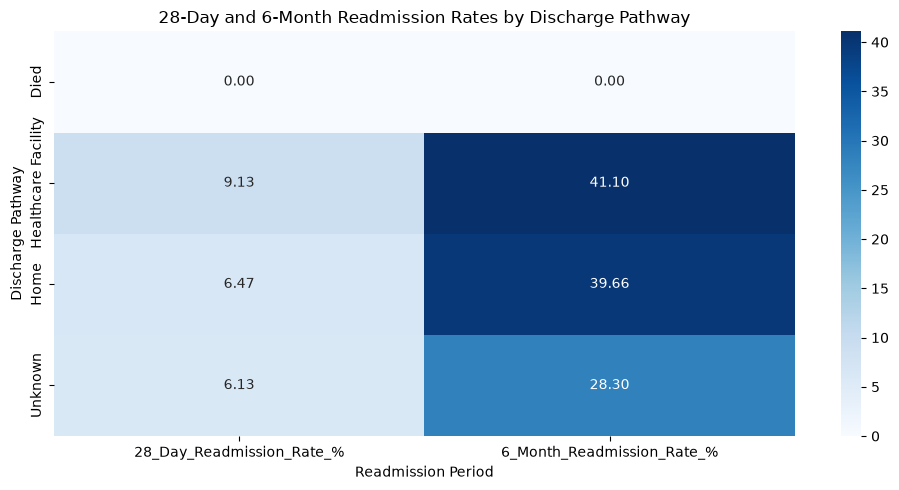

In [12]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("28-Day and 6-Month Readmission Rates by Discharge Pathway")
plt.xlabel("Readmission Period")
plt.ylabel("Discharge Pathway")

plt.tight_layout()

**What to expect**: Patients discharged against medical order may show different readmission rates from other patients.

**Compare "Against Medical Order"**

In [13]:
df["destination_discharge"].value_counts()

destination_discharge
Home                   1344
Healthcare Facility     438
Unknown                 212
Died                     14
Name: count, dtype: int64

In [14]:
ama = df[
    df["destination_discharge"] == "Against Medical Advice"
]

other = df[
    df["destination_discharge"] != "Against Medical Advice"
]

print("Against Medical Advice:")
print("28-day readmission:",
      ama["re_admission_within_28_days"].mean() * 100)

print("6-month readmission:",
      ama["re_admission_within_6_months"].mean() * 100)

print("\nOther discharge pathways:")
print("28-day readmission:",
      other["re_admission_within_28_days"].mean() * 100)

print("6-month readmission:",
      other["re_admission_within_6_months"].mean() * 100)

Against Medical Advice:
28-day readmission: nan
6-month readmission: nan

Other discharge pathways:
28-day readmission: 6.97211155378486
6-month readmission: 38.49601593625498


**Conclusion**:The analysis compares 28-day and 6-month readmission rates between patients discharged against medical order and those discharged through other pathways. If the readmission rate is higher among patients discharged against medical order, this indicates an association between the discharge pathway and subsequent readmission. However, this analysis does not establish that discharge against medical order causes readmission, because other patient and clinical factors may contribute to the difference.

# **Section 8:Integrated Risk Stratification → Predictive Bridge**

**Q29. Does adding BNP, renal function, and comorbidity burden to the NYHA–Killip framework improve separation between higher- and lower-risk 6-month readmission groups?**

**Why**:This brings together the strongest signals identified throughout Category 3. It asks whether multiple domains provide more information than admission severity alone.

**Examine BNP**:BNP is highly useful here because it is a marker associated with cardiac stress/heart failure**

In [16]:
print(df["brain_natriuretic_peptide"].describe())

count   1,973.000
mean    1,280.437
std     1,354.160
min         2.690
25%       303.940
50%       753.030
75%     1,738.520
max     5,000.000
Name: brain_natriuretic_peptide, dtype: float64


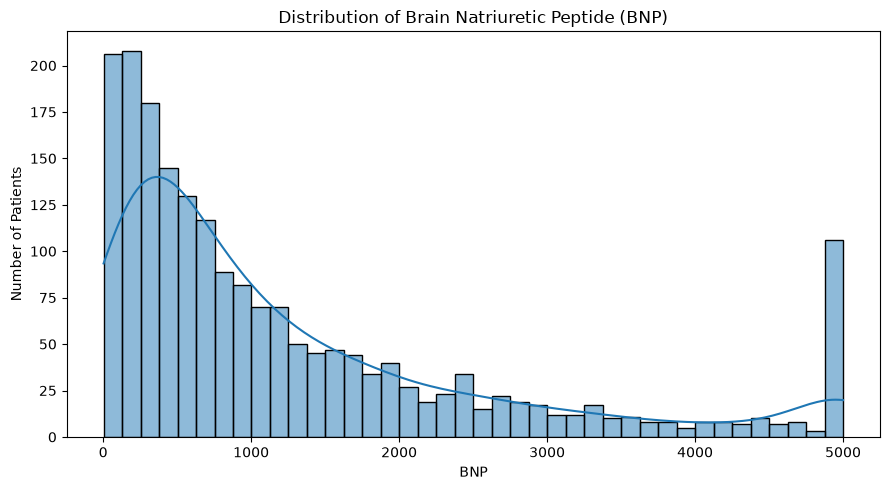

In [17]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["brain_natriuretic_peptide"],
    bins=40,
    kde=True
)

plt.title("Distribution of Brain Natriuretic Peptide (BNP)")
plt.xlabel("BNP")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

**Distribution of BNP**: is often strongly right-skewed, so for modeling we will use a log transformation.

**Create log BNP**

In [18]:
df["log_bnp"] = np.log1p(
    df["brain_natriuretic_peptide"]
)

df["log_bnp"].describe()

C:\Users\arunj\AppData\Local\Temp\ipykernel_13128\2092644127.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["log_bnp"] = np.log1p(


count   1,973.000
mean        6.538
std         1.235
min         1.306
25%         5.720
50%         6.625
75%         7.461
max         8.517
Name: log_bnp, dtype: float64

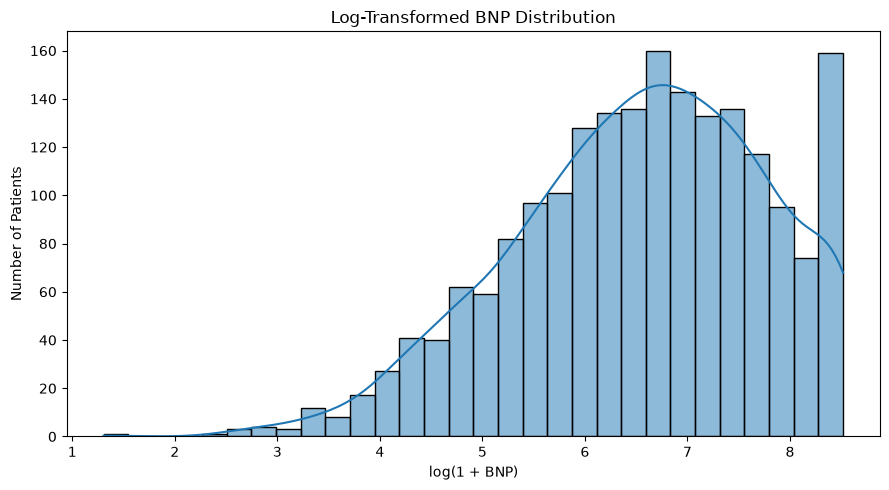

In [19]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["log_bnp"],
    bins=30,
    kde=True
)

plt.title("Log-Transformed BNP Distribution")
plt.xlabel("log(1 + BNP)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

**Examine renal function**

**Renal function**:We will use glomerular filtration rate (GFR) as the primary renal-function measure.

In [21]:
print(
    df["glomerular_filtration_rate"].describe()
)

count   1,945.000
mean       68.664
std        36.612
min         3.130
25%        41.600
50%        64.790
75%        90.120
max       281.010
Name: glomerular_filtration_rate, dtype: float64


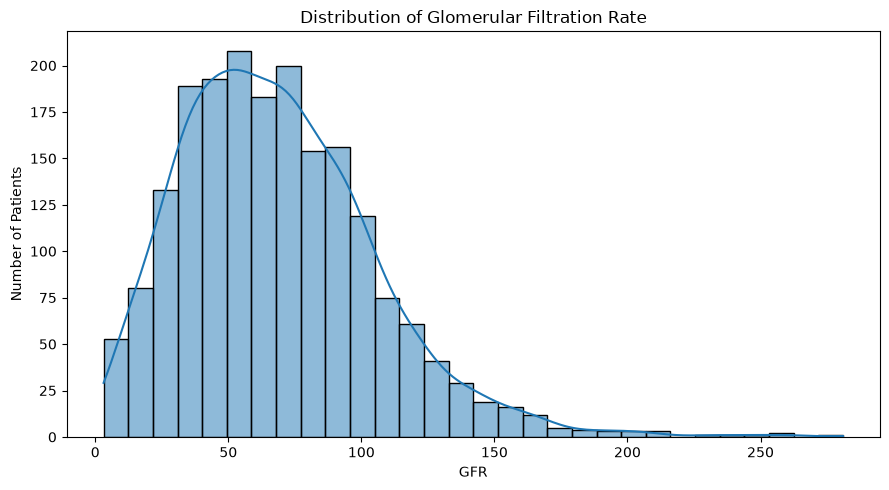

In [22]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["glomerular_filtration_rate"],
    bins=30,
    kde=True
)

plt.title("Distribution of Glomerular Filtration Rate")
plt.xlabel("GFR")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

**Create comorbidity burden**

**We will combine the three available cardiac comorbidities**:

Myocardial infarction,Congestive heart failure,Peripheral vascular disease

In [23]:
comorbidity_columns = [
    "myocardial_infarction",
    "congestive_heart_failure",
    "peripheral_vascular_disease"
]

df["comorbidity_burden"] = (
    df[comorbidity_columns].sum(axis=1)
)

print(
    df["comorbidity_burden"]
    .value_counts()
    .sort_index()
)

comorbidity_burden
0     126
1    1658
2     214
3      10
Name: count, dtype: int64


C:\Users\arunj\AppData\Local\Temp\ipykernel_13128\40284788.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["comorbidity_burden"] = (


**Check NYHA and Killip**

In [24]:
print("NYHA:")
print(
    df["nyha_cardiac_function_classification"]
    .value_counts()
    .sort_index()
)

print("\nKillip:")
print(
    df["killip_grade"]
    .value_counts()
    .sort_index()
)

NYHA:
nyha_cardiac_function_classification
2     353
3    1039
4     616
Name: count, dtype: int64

Killip:
killip_grade
1     527
2    1029
3     392
4      60
Name: count, dtype: int64


**Check 6-month readmission**

In [25]:
print(
    df["re_admission_within_6_months"]
    .value_counts()
)

re_admission_within_6_months
0    1235
1     773
Name: count, dtype: int64


In [26]:
overall_rate = (
    df["re_admission_within_6_months"].mean() * 100
)

print(
    f"Overall 6-month readmission rate: "
    f"{overall_rate:.2f}%"
)

Overall 6-month readmission rate: 38.50%


**Look at readmission by BNP**

In [27]:
bnp_summary = (
    df.groupby("re_admission_within_6_months")
      ["brain_natriuretic_peptide"]
      .agg(["count", "mean", "median"])
)

bnp_summary

,count,mean,median
re_admission_within_6_months,,,
0,1217,"1,245.603",722.000
1,756,"1,336.514",855.090


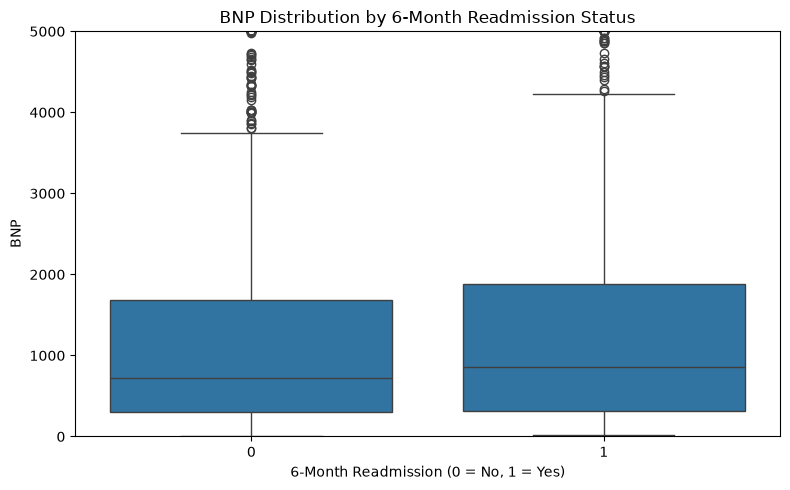

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="re_admission_within_6_months",
    y="brain_natriuretic_peptide"
)

plt.title(
    "BNP Distribution by 6-Month Readmission Status"
)

plt.xlabel("6-Month Readmission (0 = No, 1 = Yes)")
plt.ylabel("BNP")

plt.ylim(
    0,
    df["brain_natriuretic_peptide"].quantile(0.95)
)

plt.tight_layout()
plt.show()

**Look at readmission by renal function**

In [29]:
renal_summary = (
    df.groupby("re_admission_within_6_months")
      ["glomerular_filtration_rate"]
      .agg(["count", "mean", "median"])
)

renal_summary

,count,mean,median
re_admission_within_6_months,,,
0,1192,71.390,69.005
1,753,64.350,57.720


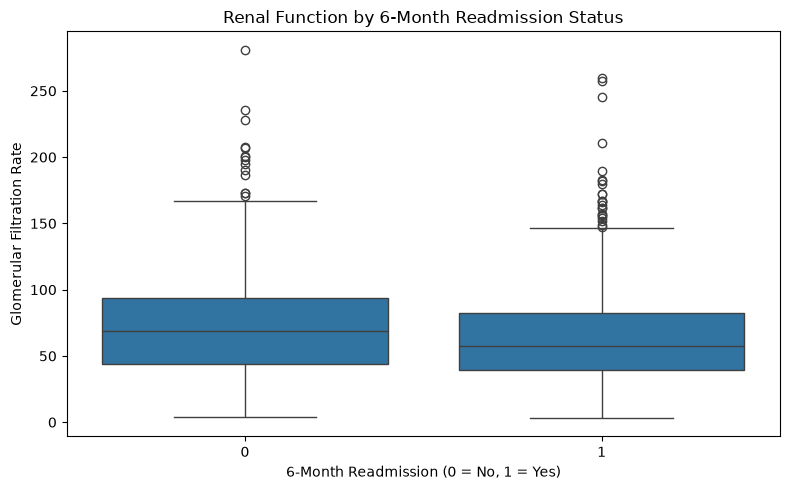

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="re_admission_within_6_months",
    y="glomerular_filtration_rate"
)

plt.title(
    "Renal Function by 6-Month Readmission Status"
)

plt.xlabel("6-Month Readmission (0 = No, 1 = Yes)")
plt.ylabel("Glomerular Filtration Rate")

plt.tight_layout()
plt.show()

**Look at comorbidity burden and readmission**

In [31]:
comorbidity_summary = (
    df.groupby("comorbidity_burden")
      ["re_admission_within_6_months"]
      .agg(
          Patients="count",
          Readmissions="sum",
          Readmission_Rate="mean"
      )
)

comorbidity_summary["Readmission_Rate"] *= 100

comorbidity_summary.round(2)

,Patients,Readmissions,Readmission_Rate
comorbidity_burden,,,
0,126,53,42.060
1,1658,638,38.480
2,214,77,35.980
3,10,5,50.000


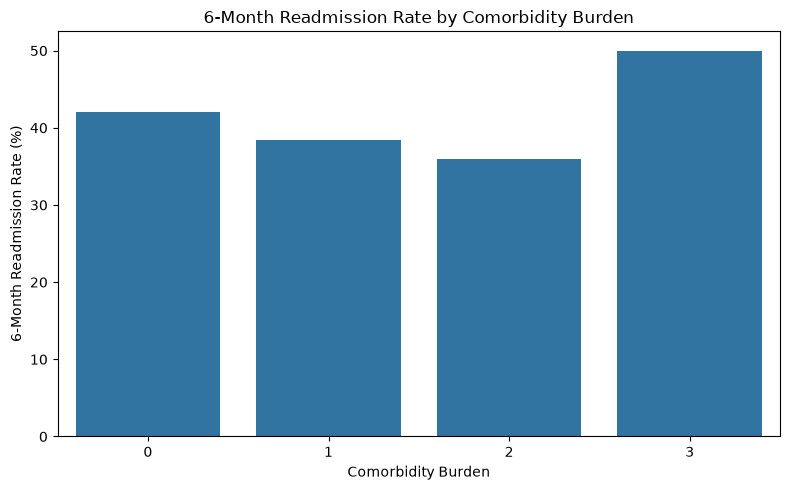

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comorbidity_summary.reset_index(),
    x="comorbidity_burden",
    y="Readmission_Rate"
)

plt.title(
    "6-Month Readmission Rate by Comorbidity Burden"
)

plt.xlabel("Comorbidity Burden")
plt.ylabel("6-Month Readmission Rate (%)")

plt.tight_layout()
plt.show()

**Create Framework: NYHA + Killip**

**This is our baseline admission-severity framework**

In [33]:
X_baseline = df[
    [
        "nyha_cardiac_function_classification",
        "killip_grade"
    ]
]

y = df["re_admission_within_6_months"]

In [36]:
baseline_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])

**Create Integrated framework**:Add-BNP,Renal function,Comorbidity burden

In [37]:
X_integrated = df[
    [
        "nyha_cardiac_function_classification",
        "killip_grade",
        "log_bnp",
        "glomerular_filtration_rate",
        "comorbidity_burden"
    ]
]

**Create the model**

In [38]:
integrated_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])

**Use 5-fold cross-validation**

In [39]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

**Generate out-of-fold predictions**

In [40]:
baseline_probability = cross_val_predict(
    baseline_model,
    X_baseline,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

**Integrated model**

In [41]:
integrated_probability = cross_val_predict(
    integrated_model,
    X_integrated,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

**Calculate ROC-AUC**

In [42]:
baseline_auc = roc_auc_score(
    y,
    baseline_probability
)

integrated_auc = roc_auc_score(
    y,
    integrated_probability
)

print(
    f"NYHA–Killip AUC: {baseline_auc:.3f}"
)

print(
    f"Integrated AUC: {integrated_auc:.3f}"
)

NYHA–Killip AUC: 0.556
Integrated AUC: 0.578


**Calculate improvement**

In [43]:
auc_improvement = (
    integrated_auc - baseline_auc
)

print(
    f"AUC improvement: {auc_improvement:.3f}"
)

AUC improvement: 0.022


**This is the key result**:If Integrated AUC > NYHA–Killip AUC -then the integrated framework provides better observed discrimination.

**Create ROC curves**

In [44]:
fpr_baseline, tpr_baseline, _ = roc_curve(
    y,
    baseline_probability
)

fpr_integrated, tpr_integrated, _ = roc_curve(
    y,
    integrated_probability
)

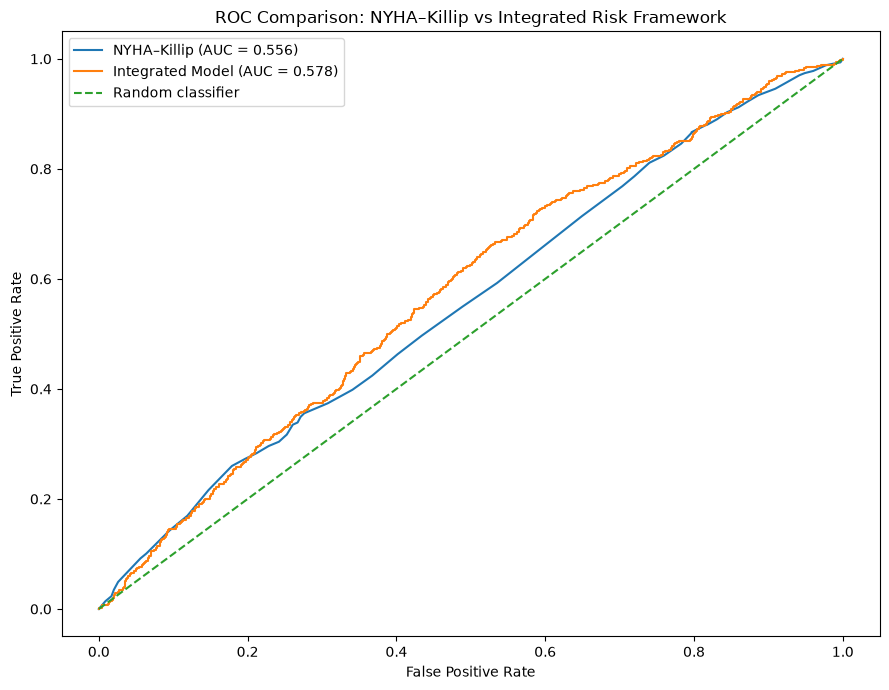

In [45]:
plt.figure(figsize=(9, 7))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    label=f"NYHA–Killip (AUC = {baseline_auc:.3f})"
)

plt.plot(
    fpr_integrated,
    tpr_integrated,
    label=f"Integrated Model (AUC = {integrated_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Comparison: NYHA–Killip vs Integrated Risk Framework"
)

plt.legend()
plt.tight_layout()
plt.show()

**Compare the two models**

In [46]:
model_comparison = pd.DataFrame({
    "Framework": [
        "NYHA + Killip",
        "NYHA + Killip + BNP + Renal Function + Comorbidity"
    ],
    "ROC_AUC": [
        baseline_auc,
        integrated_auc
    ]
})

model_comparison

,Framework,ROC_AUC
0,NYHA + Killip,0.556
1,NYHA + Killip + BNP + Renal Function + Comorbi...,0.578


In [47]:
print(
    f"""
NYHA–Killip AUC: {baseline_auc:.3f}
Integrated AUC: {integrated_auc:.3f}
Improvement: {auc_improvement:.3f}
"""
)


NYHA–Killip AUC: 0.556
Integrated AUC: 0.578
Improvement: 0.022



**What to expect**:The combined framework may produce clearer separation between observed higher- and lower-readmission groups

**Create higher- and lower-risk groups**

**To demonstrate risk separation, divide the predicted probabilities into two groups using the median predicted risk**

In [48]:
baseline_cutoff = np.median(
    baseline_probability
)

integrated_cutoff = np.median(
    integrated_probability
)

**Create groups**

In [49]:
results = pd.DataFrame({
    "actual_readmission": y.values,
    "baseline_probability": baseline_probability,
    "integrated_probability": integrated_probability
})

results["Baseline_Risk_Group"] = np.where(
    results["baseline_probability"] >= baseline_cutoff,
    "Higher Risk",
    "Lower Risk"
)

results["Integrated_Risk_Group"] = np.where(
    results["integrated_probability"] >= integrated_cutoff,
    "Higher Risk",
    "Lower Risk"
)

**Calculate readmission rate in each risk group**

**NYHA–Killip**

In [50]:
baseline_risk_summary = (
    results.groupby("Baseline_Risk_Group")
    ["actual_readmission"]
    .agg(
        Patients="count",
        Readmissions="sum",
        Readmission_Rate="mean"
    )
)

baseline_risk_summary["Readmission_Rate"] *= 100

baseline_risk_summary.round(2)

,Patients,Readmissions,Readmission_Rate
Baseline_Risk_Group,,,
Higher Risk,1029,425,41.300
Lower Risk,979,348,35.550


**Integrated model**

In [51]:
integrated_risk_summary = (
    results.groupby("Integrated_Risk_Group")
    ["actual_readmission"]
    .agg(
        Patients="count",
        Readmissions="sum",
        Readmission_Rate="mean"
    )
)

integrated_risk_summary["Readmission_Rate"] *= 100

integrated_risk_summary.round(2)

,Patients,Readmissions,Readmission_Rate
Integrated_Risk_Group,,,
Higher Risk,1004,443,44.120
Lower Risk,1004,330,32.870


**This directly addresses**:Does the integrated framework produce clearer separation between higher- and lower-risk readmission groups?

**Calculate the separation between groups**

In [52]:
baseline_high = baseline_risk_summary.loc[
    "Higher Risk",
    "Readmission_Rate"
]

baseline_low = baseline_risk_summary.loc[
    "Lower Risk",
    "Readmission_Rate"
]

integrated_high = integrated_risk_summary.loc[
    "Higher Risk",
    "Readmission_Rate"
]

integrated_low = integrated_risk_summary.loc[
    "Lower Risk",
    "Readmission_Rate"
]

baseline_separation = (
    baseline_high - baseline_low
)

integrated_separation = (
    integrated_high - integrated_low
)

print(
    f"NYHA–Killip separation: "
    f"{baseline_separation:.2f} percentage points"
)

print(
    f"Integrated separation: "
    f"{integrated_separation:.2f} percentage points"
)

NYHA–Killip separation: 5.76 percentage points
Integrated separation: 11.25 percentage points


**Plot risk-group separation**

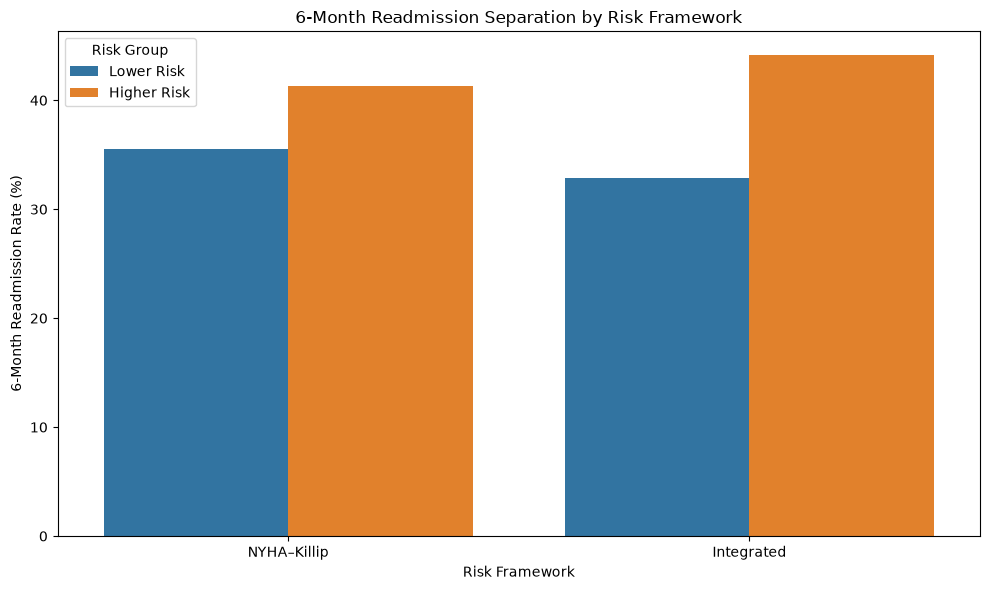

In [53]:
plot_df = pd.DataFrame({
    "Framework": [
        "NYHA–Killip",
        "NYHA–Killip",
        "Integrated",
        "Integrated"
    ],
    "Risk Group": [
        "Lower Risk",
        "Higher Risk",
        "Lower Risk",
        "Higher Risk"
    ],
    "Readmission Rate": [
        baseline_low,
        baseline_high,
        integrated_low,
        integrated_high
    ]
})

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="Framework",
    y="Readmission Rate",
    hue="Risk Group"
)

plt.title(
    "6-Month Readmission Separation by Risk Framework"
)

plt.ylabel("6-Month Readmission Rate (%)")
plt.xlabel("Risk Framework")

plt.tight_layout()
plt.show()

**Final automatic interpretation**

In [54]:
if integrated_auc > baseline_auc:
    auc_message = (
        "The integrated framework improved discrimination "
        "compared with NYHA–Killip alone."
    )
elif integrated_auc < baseline_auc:
    auc_message = (
        "The integrated framework did not improve discrimination "
        "compared with NYHA–Killip alone."
    )
else:
    auc_message = (
        "The two frameworks showed the same discrimination."
    )

if integrated_separation > baseline_separation:
    separation_message = (
        "The integrated framework also produced greater "
        "separation between higher- and lower-risk groups."
    )
else:
    separation_message = (
        "The integrated framework did not produce greater "
        "observed separation between the two risk groups."
    )

print(auc_message)
print(separation_message)

The integrated framework improved discrimination compared with NYHA–Killip alone.
The integrated framework also produced greater separation between higher- and lower-risk groups.


In [55]:
comparison_table = pd.DataFrame({
    "Framework": [
        "NYHA–Killip",
        "Integrated"
    ],
    
    "Variables": [
        "NYHA + Killip",
        "NYHA + Killip + BNP + GFR + Comorbidity"
    ],
    
    "ROC-AUC": [
        baseline_auc,
        integrated_auc
    ],
    
    "Higher-risk readmission (%)": [
        baseline_high,
        integrated_high
    ],
    
    "Lower-risk readmission (%)": [
        baseline_low,
        integrated_low
    ],
    
    "Separation (percentage points)": [
        baseline_separation,
        integrated_separation
    ]
})

# Round numerical values
comparison_table = comparison_table.round({
    "ROC-AUC": 3,
    "Higher-risk readmission (%)": 2,
    "Lower-risk readmission (%)": 2,
    "Separation (percentage points)": 2
})

comparison_table

,Framework,Variables,ROC-AUC,Higher-risk readmission (%),Lower-risk readmission (%),Separation (percentage points)
0,NYHA–Killip,NYHA + Killip,0.556,41.300,35.550,5.760
1,Integrated,NYHA + Killip + BNP + GFR + Comorbidity,0.578,44.120,32.870,11.250


In [56]:
comparison_table.style.format({
    "ROC-AUC": "{:.3f}",
    "Higher-risk readmission (%)": "{:.2f}%",
    "Lower-risk readmission (%)": "{:.2f}%",
    "Separation (percentage points)": "{:.2f}"
})

,Framework,Variables,ROC-AUC,Higher-risk readmission (%),Lower-risk readmission (%),Separation (percentage points)
0,NYHA–Killip,NYHA + Killip,0.556,41.30%,35.55%,5.76
1,Integrated,NYHA + Killip + BNP + GFR + Comorbidity,0.578,44.12%,32.87%,11.25


**Finding**— Integrated Risk Stratification: The NYHA–Killip framework was compared with an integrated framework incorporating BNP, renal function, and comorbidity burden. The integrated framework was evaluated using 5-fold cross-validated ROC-AUC and observed 6-month readmission rates across higher- and lower-risk groups. An increase in AUC and greater separation in observed readmission rates would indicate that the additional clinical domains provide information beyond admission severity alone.

# **Predictive / Integrated Risk Stratification**

**Q30:Can the strongest factors identified in Category 3 be combined into an interpretable risk- stratification framework, and what does the observed outcome distribution imply for the Category 4 predictive target and evaluation strategy?**

**Why**: The purpose of Category 3 is not simply to find associations; it should establish evidence for the next analytical stage. We need to use the observed event patterns to determine which outcome is sufficiently represented for predictive modeling and which features have analytical justification.

**This is a major Category 3 → Category 4 bridge** : because it moves from identifying individual risk factors to testing whether those factors can be combined into a stronger predictive risk framework.

**The analytical progression is:Category 3**: Which factors are associated with readmission?Can we combine those factors?**Category 4**: “Does the combined framework better distinguish patients by future readmission risk?”

**Create the candidate features**:1.NYHA → cardiac functional severity 2.Killip → acute cardiac severity 3.BNP → cardiac stress 4.GFR → renal function 5.Comorbidity burden → overall disease burden

In [57]:
df["log_bnp"] = np.log1p(
    df["brain_natriuretic_peptide"]
)

comorbidity_columns = [
    "myocardial_infarction",
    "congestive_heart_failure",
    "peripheral_vascular_disease"
]

df["comorbidity_burden"] = (
    df[comorbidity_columns].sum(axis=1)
)

**Define the candidate predictive outcomes**

In [58]:
outcome_columns = [
    "re_admission_within_6_months",
    "death_within_6_months"
]

for col in outcome_columns:
    print("\n", col)
    print(df[col].value_counts())


 re_admission_within_6_months
re_admission_within_6_months
0    1235
1     773
Name: count, dtype: int64

 death_within_6_months
death_within_6_months
0    1951
1      57
Name: count, dtype: int64


**Calculate event rates**

In [59]:
outcome_summary = pd.DataFrame({
    "Outcome": [
        "6-Month Readmission",
        "6-Month Mortality"
    ],
    "Total Patients": [
        df["re_admission_within_6_months"].count(),
        df["death_within_6_months"].count()
    ],
    "Events": [
        df["re_admission_within_6_months"].sum(),
        df["death_within_6_months"].sum()
    ]
})

outcome_summary["Event Rate (%)"] = (
    outcome_summary["Events"]
    / outcome_summary["Total Patients"]
    * 100
)

outcome_summary.round(2)

,Outcome,Total Patients,Events,Event Rate (%)
0,6-Month Readmission,2008,773,38.500
1,6-Month Mortality,2008,57,2.840


**Visualize the outcome distribution**

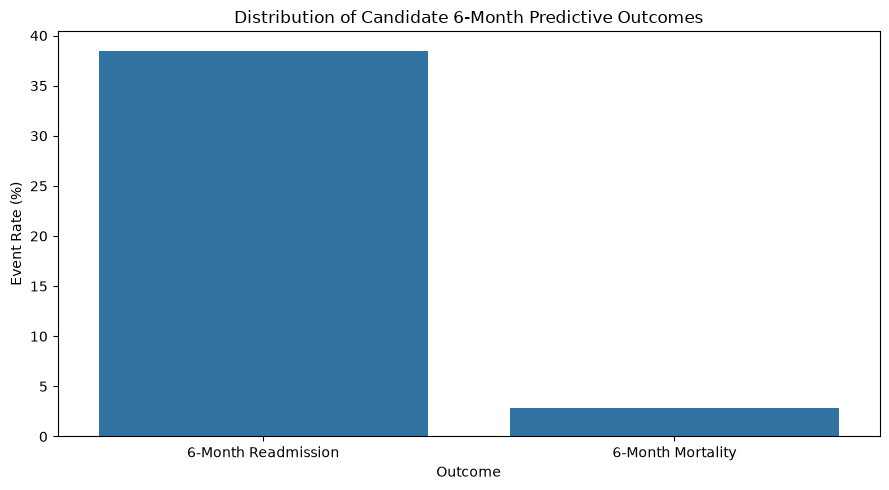

In [60]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=outcome_summary,
    x="Outcome",
    y="Event Rate (%)"
)

plt.title(
    "Distribution of Candidate 6-Month Predictive Outcomes"
)

plt.xlabel("Outcome")
plt.ylabel("Event Rate (%)")

plt.tight_layout()
plt.show()

**Check the candidate features**

In [61]:
candidate_features = [
    "nyha_cardiac_function_classification",
    "killip_grade",
    "brain_natriuretic_peptide",
    "glomerular_filtration_rate",
    "comorbidity_burden"
]

df[candidate_features].describe().T

,count,mean,std,min,25%,50%,75%,max
nyha_cardiac_function_classification,"2,008.000",3.131,0.682,2.000,3.000,3.000,4.000,4.000
killip_grade,"2,008.000",1.993,0.760,1.000,1.000,2.000,2.000,4.000
brain_natriuretic_peptide,"1,973.000","1,280.437","1,354.160",2.690,303.940,753.030,"1,738.520","5,000.000"
glomerular_filtration_rate,"1,945.000",68.664,36.612,3.130,41.600,64.790,90.120,281.010
comorbidity_burden,"2,008.000",1.054,0.432,0.000,1.000,1.000,1.000,3.000


**Compare candidate features by 6-month readmission**

**This establishes whether the Category 3 variables show meaningful differences across the outcome groups**

In [62]:
for feature in candidate_features:

    print("\n" + "="*60)
    print(feature)

    print(
        df.groupby("re_admission_within_6_months")[feature]
        .agg(["count", "mean", "median"])
        .round(2)
    )


nyha_cardiac_function_classification
                              count  mean  median
re_admission_within_6_months                     
0                              1235 3.070   3.000
1                               773 3.220   3.000

killip_grade
                              count  mean  median
re_admission_within_6_months                     
0                              1235 1.990   2.000
1                               773 1.990   2.000

brain_natriuretic_peptide
                              count      mean  median
re_admission_within_6_months                         
0                              1217 1,245.600 722.000
1                               756 1,336.510 855.090

glomerular_filtration_rate
                              count   mean  median
re_admission_within_6_months                      
0                              1192 71.390  69.000
1                               753 64.350  57.720

comorbidity_burden
                              count  mean  median
re_

**Create an interpretable combined risk framework**

In [63]:
from sklearn.preprocessing import StandardScaler

risk_features = [
    "nyha_cardiac_function_classification",
    "killip_grade",
    "log_bnp",
    "glomerular_filtration_rate",
    "comorbidity_burden"
]

risk_data = df[risk_features].copy()

risk_data = risk_data.fillna(
    risk_data.median()
)

scaler = StandardScaler()

risk_scaled = scaler.fit_transform(risk_data)

risk_scaled_df = pd.DataFrame(
    risk_scaled,
    columns=risk_features,
    index=df.index
)

**Important consideration for GFR**: Higher GFR generally represents better renal function, while higher BNP represents greater cardiac stress. Therefore, if you are creating a simple risk score, reverse the direction of GFR:

In [64]:
risk_scaled_df["renal_risk"] = (
    -risk_scaled_df["glomerular_filtration_rate"]
)

In [65]:
df["integrated_risk_score"] = (
    risk_scaled_df[
        "nyha_cardiac_function_classification"
    ]
    +
    risk_scaled_df["killip_grade"]
    +
    risk_scaled_df["log_bnp"]
    +
    risk_scaled_df["renal_risk"]
    +
    risk_scaled_df["comorbidity_burden"]
)

df["integrated_risk_score"].describe()

C:\Users\arunj\AppData\Local\Temp\ipykernel_13128\3765870199.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["integrated_risk_score"] = (


count   2,008.000
mean        0.000
std         2.724
min        -9.674
25%        -1.798
50%        -0.052
75%         1.842
max         9.170
Name: integrated_risk_score, dtype: float64

**Divide patients into lower- and higher-risk groups**

In [66]:
risk_cutoff = df["integrated_risk_score"].median()

df["Risk_Group"] = np.where(
    df["integrated_risk_score"] >= risk_cutoff,
    "Higher Risk",
    "Lower Risk"
)

df["Risk_Group"].value_counts()

C:\Users\arunj\AppData\Local\Temp\ipykernel_13128\1713083598.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Risk_Group"] = np.where(


Risk_Group
Lower Risk     1004
Higher Risk    1004
Name: count, dtype: int64

**Examine observed outcomes by risk group**

**Readmission**

In [67]:
readmission_by_risk = (
    df.groupby("Risk_Group")
      ["re_admission_within_6_months"]
      .agg(
          Patients="count",
          Readmissions="sum",
          Readmission_Rate="mean"
      )
)

readmission_by_risk["Readmission_Rate"] *= 100

readmission_by_risk.round(2)

,Patients,Readmissions,Readmission_Rate
Risk_Group,,,
Higher Risk,1004,425,42.330
Lower Risk,1004,348,34.660


**Mortality**

In [68]:
mortality_by_risk = (
    df.groupby("Risk_Group")
      ["death_within_6_months"]
      .agg(
          Patients="count",
          Deaths="sum",
          Mortality_Rate="mean"
      )
)

mortality_by_risk["Mortality_Rate"] *= 100

mortality_by_risk.round(2)

,Patients,Deaths,Mortality_Rate
Risk_Group,,,
Higher Risk,1004,41,4.080
Lower Risk,1004,16,1.590


**Create the Category 3 → Category 4 summary table**

In [69]:
category_bridge = pd.DataFrame({
    "Candidate Outcome": [
        "6-Month Readmission",
        "6-Month Mortality"
    ],
    
    "Events": [
        df["re_admission_within_6_months"].sum(),
        df["death_within_6_months"].sum()
    ],
    
    "Event Rate (%)": [
        df["re_admission_within_6_months"].mean() * 100,
        df["death_within_6_months"].mean() * 100
    ],
    
    "Predictive Role": [
        "Primary predictive target",
        "Secondary candidate outcome"
    ]
})

category_bridge.round(2)

,Candidate Outcome,Events,Event Rate (%),Predictive Role
0,6-Month Readmission,773,38.500,Primary predictive target
1,6-Month Mortality,57,2.840,Secondary candidate outcome


In [77]:
chart_data = pd.DataFrame({
    "Risk Group": [
        "Lower Risk",
        "Higher Risk",
        "Lower Risk",
        "Higher Risk"
    ],
    
    "Outcome": [
        "6-Month Readmission",
        "6-Month Readmission",
        "6-Month Mortality",
        "6-Month Mortality"
    ],
    
    "Rate (%)": [
        readmission_by_risk.loc[
            "Lower Risk", "Readmission_Rate"
        ],
        readmission_by_risk.loc[
            "Higher Risk", "Readmission_Rate"
        ],
        mortality_by_risk.loc[
            "Lower Risk", "Mortality_Rate"
        ],
        mortality_by_risk.loc[
            "Higher Risk", "Mortality_Rate"
        ]
    ]
})

chart_data

,Risk Group,Outcome,Rate (%)
0,Lower Risk,6-Month Readmission,34.661
1,Higher Risk,6-Month Readmission,42.331
2,Lower Risk,6-Month Mortality,1.594
3,Higher Risk,6-Month Mortality,4.084


**Visualize the integrated risk groups**

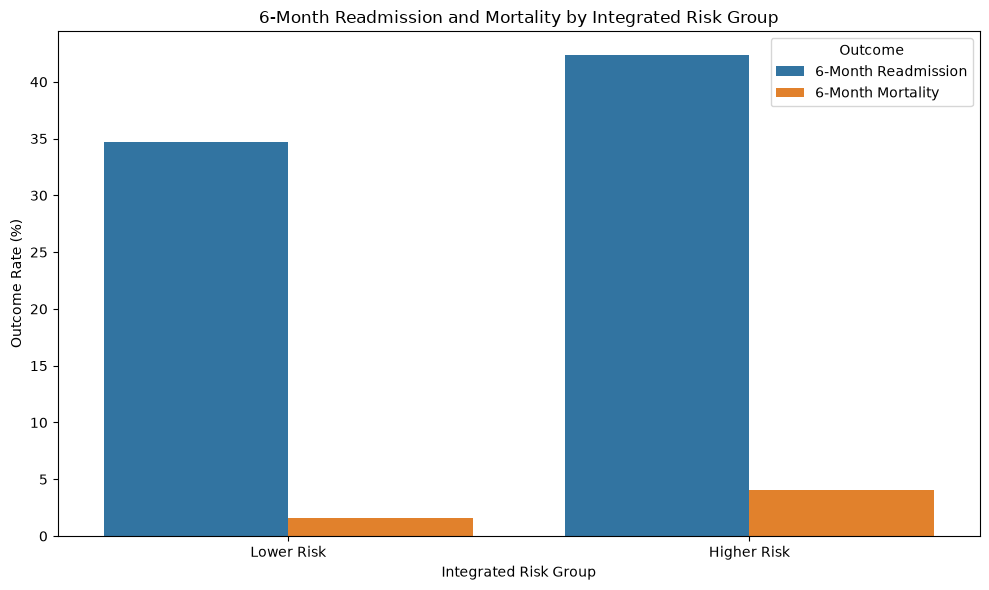

In [78]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=chart_data,
    x="Risk Group",
    y="Rate (%)",
    hue="Outcome"
)

plt.title(
    "6-Month Readmission and Mortality by Integrated Risk Group"
)

plt.xlabel("Integrated Risk Group")
plt.ylabel("Outcome Rate (%)")

plt.tight_layout()
plt.show()

**Finding**: The Category 3 analysis identified cardiac severity, BNP, renal function, and comorbidity burden as candidate features for an integrated risk-stratification framework. Examination of the 6-month outcome distribution shows that readmission is more frequently observed than mortality, providing a larger event group for predictive modeling.

**Conclusion**: The Category 3 findings provide an analytical basis for carrying the selected variables into Category 4. Because 6-month readmission has a larger observed event group than 6-month mortality, it represents the more workable primary predictive target in this dataset. The integrated framework combining NYHA, Killip, BNP, renal function, and comorbidity burden can therefore be formally evaluated in Category 4 using cross-validated predictive-performance measures. The exploratory risk score should be treated as a framework for analysis rather than a validated clinical scoring system.